In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pyreadr
from jax.experimental.ode import odeint
from jax.random import PRNGKey
from numpyro.infer import MCMC, NUTS, init_to_sample

In [8]:
seed = 739485

In [2]:
df = pyreadr.read_r('data/data.Rda')[None]
df.head().style.hide(axis='index')

y,time
0.795570,0.000000
0.174560,0.500000
0.774322,1.000000
3.083851,1.500000
2.163227,2.000000


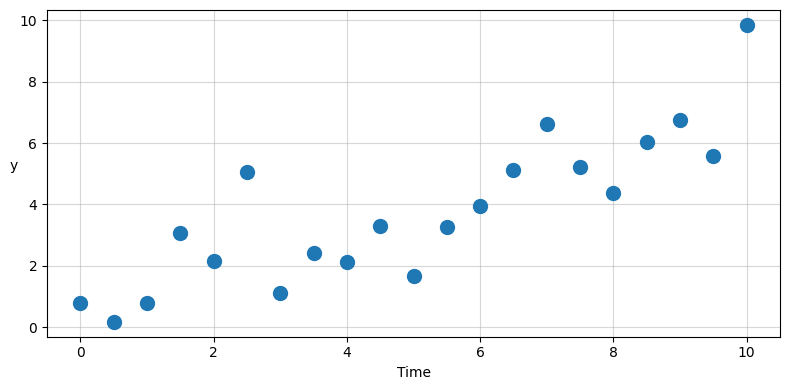

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(alpha=.5)
ax.scatter(df['time'], df['y'], s=100, zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel(ylabel='y', rotation=0.)
fig.tight_layout()

In [4]:
def f(t, z, R, K):
    dz_dt = z*R*(1 - z/K)

    return dz_dt

def model(t, y=None):
    y0 = numpyro.sample('y0', dist.Normal(0., 1.))
    S = numpyro.sample('S', dist.Normal(jnp.zeros(1), jnp.ones(1)))
    R = numpyro.sample('R', dist.Normal(jnp.zeros(1), jnp.ones(1)))
    K = numpyro.sample('K', dist.Normal(10.*jnp.ones(1), jnp.ones(1)))
    z = odeint(f, y0, t, R, K)

    if y is not None:
        numpyro.sample('y', dist.Normal(z, S), obs=y)
    else:
        numpyro.sample('y', dist.Normal(z, S))

In [9]:
fit = MCMC(NUTS(model, init_strategy=init_to_sample()), num_warmup=1000, num_samples=1000, num_chains=4, progress_bar=True)
fit.run(PRNGKey(seed), t=df['time'].to_numpy(), y=df['y'].to_numpy())

/var/folders/w0/kb7t6q915g10chsx4k3m7swc0000gp/T/ipykernel_15342/1451136435.py:1: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  fit = MCMC(NUTS(model, init_strategy=init_to_sample()), num_warmup=1000, num_samples=1000, num_chains=4, progress_bar=True)
sample: 100%|██████████| 2000/2000 [00:01<00:00, 1882.04it/s, 15 steps of size 2.75e-01. acc. prob=0.96]


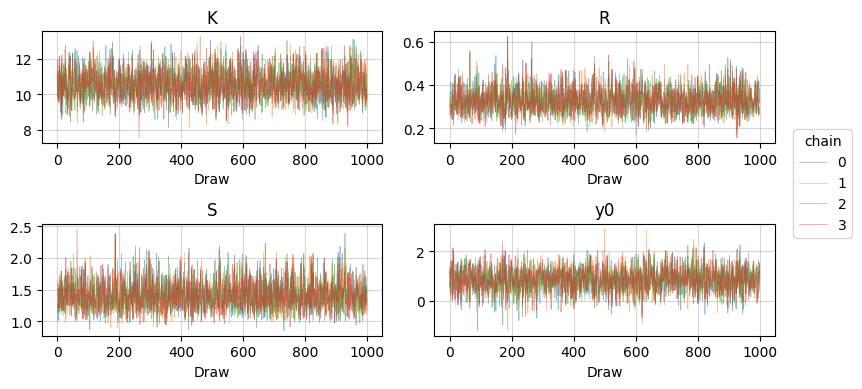

In [10]:
params = (draws := fit.get_samples()).keys()
fig, axes = plt.subplots(round(len(params)/2), 2, figsize=(8, 4))

for ax, param in zip(axes.flatten(), params):
    ax.grid(alpha=.5)
    param_draws = draws[param].reshape(fit.num_samples, fit.num_chains)
    param_lines = ax.plot(param_draws, alpha=.5, linewidth=.5)
    ax.set(title=param, xlabel='Draw')

fig.legend(param_lines, jnp.arange(fit.num_chains), title='chain', bbox_to_anchor=(1.08, .68))
fig.tight_layout()

In [11]:
fit.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      K[0]     10.58      0.83     10.57      9.21     11.95   2237.62      1.00
      R[0]      0.33      0.06      0.32      0.23      0.42   1616.68      1.00
      S[0]      1.41      0.23      1.39      1.03      1.76   2165.31      1.00
        y0      0.86      0.48      0.88      0.10      1.67   1797.05      1.00

Number of divergences: 0
